# States & Nodes

In [ ]:
from IPython.display import Image, display
from typing import TypedDict
from langgraph.graph import END, START, StateGraph

In [ ]:
# Define the schema representing the state shared between nodes in the graph
class State(TypedDict):
    name: str

In [ ]:
# Define a simple node that prints a hello greeting and returns the state unchanged
def hello_node(state: State) -> State:
    print(f"Hello, {state['name']}!")
    return state

In [ ]:
# Initialize the graph builder, register the hello node, and establish edges
builder = StateGraph(State)

builder.add_node("hello", hello_node)

builder.add_edge(START, "hello")
builder.add_edge("hello", END)

# Compile the graph builder into a runnable workflow
graph = builder.compile()

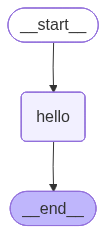

In [10]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
initial_state = State(name="Alice")

graph.invoke(initial_state)

Hello, Alice!


{'name': 'Alice'}